In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import zipfile
import os

zip_path = "/content/FruitinAmazon.zip"
extract_path = "/content/FruitinAmazon"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")
print(os.listdir(extract_path))

Unzipped successfully!
['FruitinAmazon']


In [3]:
for root, dirs, files in os.walk("/content/FruitinAmazon"):
    print("ROOT:", root)
    print("DIRS:", dirs)
    print("FILES:", files[:5])
    print("-" * 50)

ROOT: /content/FruitinAmazon
DIRS: ['FruitinAmazon']
FILES: []
--------------------------------------------------
ROOT: /content/FruitinAmazon/FruitinAmazon
DIRS: ['test', 'train']
FILES: []
--------------------------------------------------
ROOT: /content/FruitinAmazon/FruitinAmazon/test
DIRS: ['pupunha', 'graviola', 'guarana', 'acai', 'tucuma', 'cupuacu']
FILES: []
--------------------------------------------------
ROOT: /content/FruitinAmazon/FruitinAmazon/test/pupunha
DIRS: []
FILES: ['download (2).jpeg', 'download (3).jpeg', 'download (11).jpeg', 'download (4).jpeg', 'download (1).jpeg']
--------------------------------------------------
ROOT: /content/FruitinAmazon/FruitinAmazon/test/graviola
DIRS: []
FILES: ['images (4).jpeg', 'download (2).jpeg', 'download (3).jpeg', 'download (4).jpeg', 'download (1).jpeg']
--------------------------------------------------
ROOT: /content/FruitinAmazon/FruitinAmazon/test/guarana
DIRS: []
FILES: ['images (4).jpeg', 'download (2).jpeg', 'downloa

In [4]:
train_dir = "/content/FruitinAmazon/FruitinAmazon/train"
test_dir = "/content/FruitinAmazon/FruitinAmazon/test"

class_names = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print("Class names:", class_names)
print("Number of classes:", len(class_names))

Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [5]:
sample_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random_image = random.choice(image_files)
    sample_images.append((class_name, os.path.join(class_path, random_image)))

print(sample_images)

[('acai', '/content/FruitinAmazon/FruitinAmazon/train/acai/images (7).jpeg'), ('cupuacu', '/content/FruitinAmazon/FruitinAmazon/train/cupuacu/images (2).jpeg'), ('graviola', '/content/FruitinAmazon/FruitinAmazon/train/graviola/images (8).jpeg'), ('guarana', '/content/FruitinAmazon/FruitinAmazon/train/guarana/images (3).jpeg'), ('pupunha', '/content/FruitinAmazon/FruitinAmazon/train/pupunha/images (1).jpeg'), ('tucuma', '/content/FruitinAmazon/FruitinAmazon/train/tucuma/download (6).jpeg')]


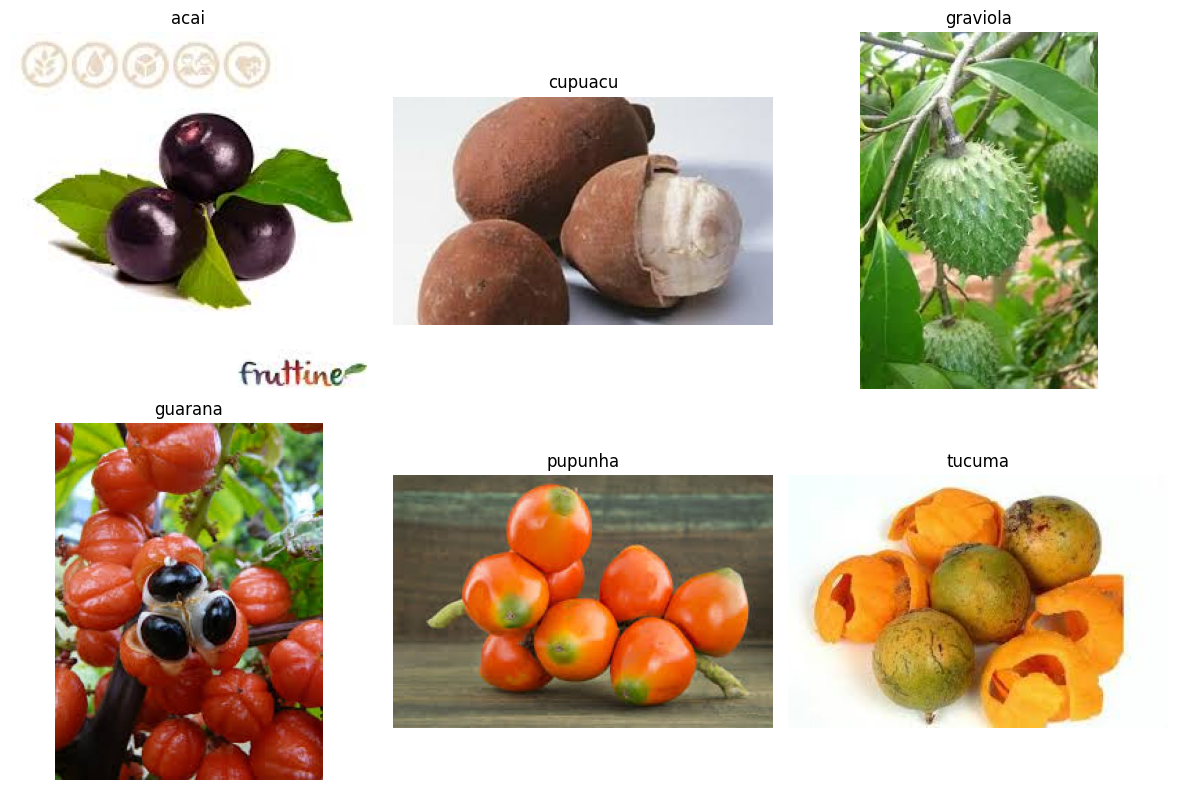

In [6]:
plt.figure(figsize=(12, 8))

rows = 2
cols = 3

for i, (class_name, image_path) in enumerate(sample_images):
    img = Image.open(image_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
def remove_corrupted_images(directory):
    corrupted_files = []

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)

            try:
                with Image.open(file_path) as img:
                    img.verify()
            except Exception:
                corrupted_files.append(file_path)
                os.remove(file_path)
                print("Removed corrupted image:", file_path)

    if not corrupted_files:
        print("No Corrupted Images Found.")

    return corrupted_files

In [8]:
print("Checking train folder...")
train_corrupted = remove_corrupted_images(train_dir)

print("\nChecking test folder...")
test_corrupted = remove_corrupted_images(test_dir)

Checking train folder...
No Corrupted Images Found.

Checking test folder...
No Corrupted Images Found.


In [9]:
print("Checking train folder...")
train_corrupted = remove_corrupted_images(train_dir)

print("\nChecking test folder...")
test_corrupted = remove_corrupted_images(test_dir)

Checking train folder...
No Corrupted Images Found.

Checking test folder...
No Corrupted Images Found.


In [10]:
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

In [11]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=seed
)

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [12]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=seed
)

Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [13]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 30 files belonging to 6 classes.


In [14]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [15]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

In [16]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [17]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(32, (3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    "best_fruit_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [21]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.2198 - loss: 1.9974
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 363ms/step - accuracy: 0.1667 - loss: 2.0021 - val_accuracy: 0.0000e+00 - val_loss: 1.7555
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.1444 - loss: 1.7388
Epoch 2: val_accuracy improved from 0.00000 to 0.55556, saving model to best_fruit_model.h5



Epoch 2: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - accuracy: 0.1806 - loss: 1.6874 - val_accuracy: 0.5556 - val_loss: 1.6118
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.4552 - loss: 1.4638
Epoch 3: val_accuracy did not improve from 0.55556
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 308ms/step - accuracy: 0.4583 - loss: 1.3924 - val_accuracy: 0.5556 - val_loss: 1.0656
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.6198 - loss: 1.1044
Epoch 4: val_accuracy improved from 0.55556 to 0.88889, saving model to best_fruit_model.h5



Epoch 4: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 415ms/step - accuracy: 0.6667 - loss: 0.9953 - val_accuracy: 0.8889 - val_loss: 0.8153
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.7469 - loss: 0.8255
Epoch 5: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step - accuracy: 0.7917 - loss: 0.6960 - val_accuracy: 0.8333 - val_loss: 0.7582
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.9229 - loss: 0.4645
Epoch 6: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step - accuracy: 0.9167 - loss: 0.4018 - val_accuracy: 0.6111 - val_loss: 1.2909
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.9264 - loss: 0.3127
Epoch 7: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step - accuracy: 0.9444 - loss: 0.2468 - val_accuracy: 0.8333 - val_loss: 0.3449
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.8747 - loss:

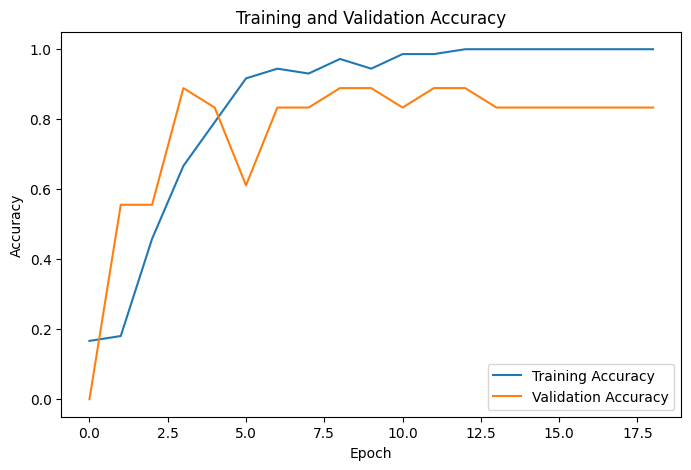

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

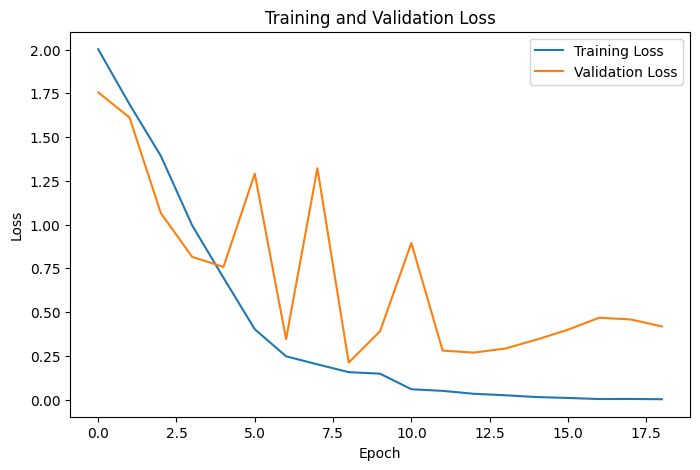

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [24]:
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6667 - loss: 0.9574
Test Loss: 0.9574335813522339
Test Accuracy: 0.6666666865348816


In [25]:
model.save("fruit_classifier_final.h5")
print("Model saved successfully.")

Model saved successfully.


In [26]:
loaded_model = tf.keras.models.load_model("fruit_classifier_final.h5")
print("Model loaded successfully.")

Model loaded successfully.


In [27]:
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds)
print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.6667 - loss: 0.9574
Loaded Model Test Loss: 0.9574335813522339
Loaded Model Test Accuracy: 0.6666666865348816


In [28]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [29]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       1.00      0.60      0.75         5
     cupuacu       0.42      1.00      0.59         5
    graviola       1.00      0.60      0.75         5
     guarana       0.71      1.00      0.83         5
     pupunha       1.00      0.40      0.57         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.67        30
   macro avg       0.80      0.67      0.67        30
weighted avg       0.80      0.67      0.67        30



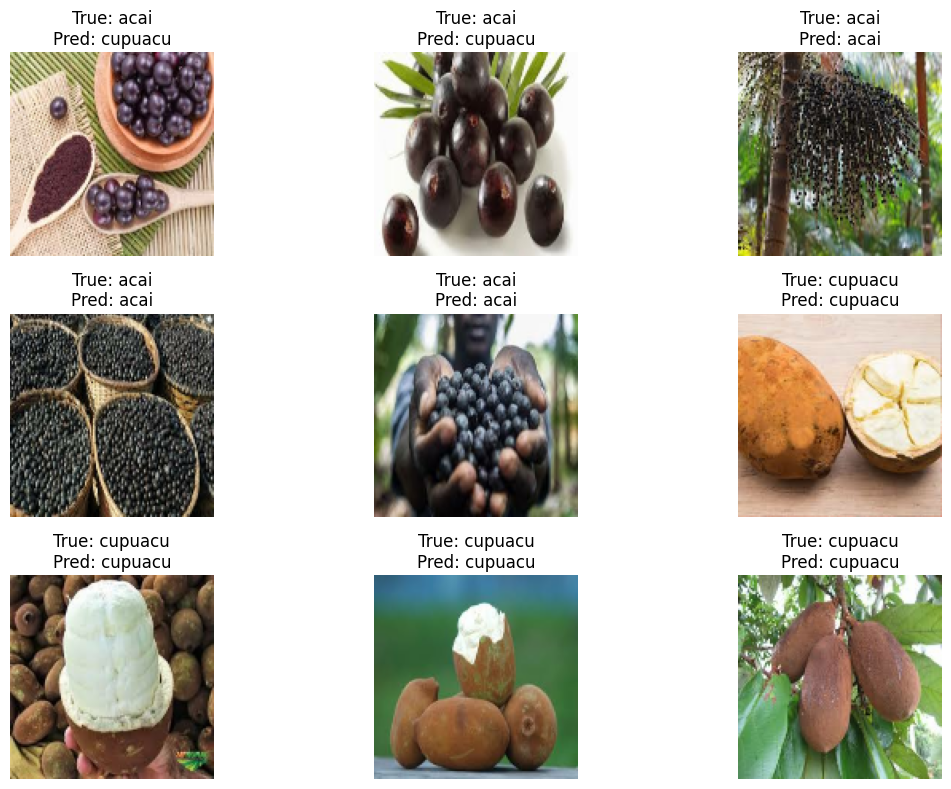

In [30]:
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[predicted_labels[i]]}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
import os

if os.path.exists("fruit_classifier_final.h5"):
    print("Model file exists.")
    print("File name:", "fruit_classifier_final.h5")
    print("File size:", os.path.getsize("fruit_classifier_final.h5"), "bytes")
else:
    print("Model file not found.")

Model file exists.
File name: fruit_classifier_final.h5
File size: 25442992 bytes


In [33]:
loaded_model = tf.keras.models.load_model("fruit_classifier_final.h5")
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,456 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)